# BiTimelyGPT for PhysioNet 2012 Challenge

SOS token handling test

In [ ]:
# import libraries
import os
import torch
import numpy as np
import pandas as pd
from torch import nn, optim
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, auc
import matplotlib.pyplot as plt
import copy


In [ ]:
# mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# BiTimelyGPT to path
import sys
sys.path.append('/content/drive/MyDrive/BiTimelyGPT-main/BiTimelyGPT')

Mounted at /content/drive


In [ ]:
# import BiTimelyGPT modules
from data.data_pipeline import physionet_data_pipeline
from models.BiTimelyGPT import BiTimelyGPT
from layers.heads import PretrainHead, ClfHead
from layers.optimization import get_linear_schedule_with_warmup, AdamW

In [ ]:
# define paths to PhysioNet 2012 data in Google Drive
google_drive_folder = '/content/drive/MyDrive/physionet2012/'
set_a_directory = f"{google_drive_folder}/set-a"
set_b_directory = f"{google_drive_folder}/set-b"
set_c_directory = f"{google_drive_folder}/set-c"

outcomes_a_file = f"{set_a_directory}/Outcomes-a.txt"
outcomes_b_file = f"{set_b_directory}/Outcomes-b.txt"
outcomes_c_file = f"{set_c_directory}/Outcomes-c.txt"

In [ ]:
class PhysioNetConfig:
    def __init__(self):
        self.feature_list = [
            'Albumin', 'ALP', 'ALT', 'AST', 'Bilirubin', 'BUN', 'Cholesterol',
            'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT',
            'HR', 'K', 'Lactate', 'Mg', 'MAP', 'MechVent', 'Na', 'NIDiasABP',
            'NIMAP', 'NISysABP', 'PaCO2', 'PaO2', 'pH', 'Platelets', 'RespRate',
            'SaO2', 'SysABP', 'Temp', 'TropI', 'TropT', 'Urine', 'WBC', 'Weight'
        ]

        self.num_layers = 8
        self.num_heads = 4
        self.d_model = 144
        self.qk_dim = 144
        self.v_dim = 288
        self.ffn_proj_size = 576
        self.d_ff = 288
        self.dropout = 0.1
        self.n_output = len(self.feature_list)
        self.n_clf_output = 2


        self.pretrain_batch_size = 32
        self.pretrain_learning_rate = 1e-4
        self.pretrain_epochs = 20
        self.pretrain_warmup_steps = 500

        self.finetune_batch_size = 32
        self.finetune_learning_rate = 3e-4
        self.finetune_epochs = 50
        self.finetune_warmup_steps = 1000
        self.gradient_clip = 1.0

        self.use_bias_in_msr = False
        self.use_bias_in_mlp = True
        self.use_bias_in_msr_out = False
        self.use_default_gamma = False
        self.forward_impl = 'chunkwise'
        self.chunk_size = 12
        self.seq_len = 2880
        self.chunk_size = 60
        self.activation = 'gelu'
        self.head_type = 'clf'

        self.use_gpu = torch.cuda.is_available()
        self.use_grad_ckp = False
        self.use_grad_accum = True
        self.accum_steps = 4
        self.use_amp = True
        self.use_multi_gpu = False
        self.devices = '0'

        self.output_retentions = False

config = PhysioNetConfig()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(42)
np.random.seed(42)

model = BiTimelyGPT(configs=config, head_type='pretrain').to(device)
print("Initial model created with Pretrain head.")

Initial model created with Pretrain head.


In [ ]:
# load training data
config.batch_size = config.pretrain_batch_size
train_data_path = set_a_directory
train_outcomes_path = outcomes_a_file
train_dataset, train_loader = physionet_data_pipeline(
    train_data_path,
    train_outcomes_path,
    config,
    split='train'
)

# load validation data
config.batch_size = config.finetune_batch_size
val_data_path = set_b_directory
val_outcomes_path = outcomes_b_file
val_dataset, val_loader = physionet_data_pipeline(
    val_data_path,
    val_outcomes_path,
    config,
    split='val'
)

# load test data (set-c) for final metrics
test_data_path = set_c_directory
test_outcomes_path = outcomes_c_file
test_dataset, test_loader = physionet_data_pipeline(
    test_data_path,
    test_outcomes_path,
    config,
    split='test'
)



In [ ]:
########################################
# Define optimizer, scheduler
########################################
print("--- Starting Pretraining Phase ---")

pretrain_optimizer = AdamW(
    model.parameters(),
    lr=config.pretrain_learning_rate,
    weight_decay=0.01
)

num_pretraining_steps = len(train_loader) * config.pretrain_epochs
pretrain_scheduler = get_linear_schedule_with_warmup(
   pretrain_optimizer,
   config.pretrain_warmup_steps,
   num_pretraining_steps
)

pretrain_criterion = nn.MSELoss()

--- Starting Pretraining Phase ---


In [ ]:
# --- Pretraining Loop ---
for epoch in range(config.pretrain_epochs):
    model.train()
    pretrain_losses = []

    for i, batch_data in enumerate(train_loader):
        batch_x, _, attention_mask = [b.to(device) for b in batch_data]

        if i % config.accum_steps == 0:
            pretrain_optimizer.zero_grad()

        loss = model(batch_x, y=None,
                     retention_mask=None,
                     forward_impl=config.forward_impl,
                     chunk_size=config.chunk_size)

        if torch.isnan(loss):
             print(f"Warning: NaN loss encountered at pretrain epoch {epoch+1}, batch {i}. Skipping batch.")
             pretrain_optimizer.zero_grad()
             continue

        scaled_loss = loss / config.accum_steps
        scaled_loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip)

        if (i + 1) % config.accum_steps == 0 or (i + 1) == len(train_loader):
            pretrain_optimizer.step()
            pretrain_scheduler.step()

        pretrain_losses.append(loss.item())

    avg_pretrain_loss = np.mean(pretrain_losses)
    print(f'Pretrain Epoch {epoch+1}/{config.pretrain_epochs} -- Avg Loss: {avg_pretrain_loss:.4f}')

print("--- Pretraining Phase Complete ---")

Pretrain Epoch 1/20 -- Avg Loss: 111.4984
Pretrain Epoch 2/20 -- Avg Loss: 104.5940
Pretrain Epoch 3/20 -- Avg Loss: 93.0635
Pretrain Epoch 4/20 -- Avg Loss: 76.3404
Pretrain Epoch 5/20 -- Avg Loss: 62.4433
Pretrain Epoch 6/20 -- Avg Loss: 51.6004
Pretrain Epoch 7/20 -- Avg Loss: 37.6883
Pretrain Epoch 8/20 -- Avg Loss: 27.3663
Pretrain Epoch 9/20 -- Avg Loss: 18.2862
Pretrain Epoch 10/20 -- Avg Loss: 11.7259
Pretrain Epoch 11/20 -- Avg Loss: 6.9042
Pretrain Epoch 12/20 -- Avg Loss: 3.7245
Pretrain Epoch 13/20 -- Avg Loss: 1.9305
Pretrain Epoch 14/20 -- Avg Loss: 0.7165
Pretrain Epoch 15/20 -- Avg Loss: 0.2438
Pretrain Epoch 16/20 -- Avg Loss: 0.0449
Pretrain Epoch 17/20 -- Avg Loss: 0.0083
Pretrain Epoch 18/20 -- Avg Loss: 0.0035
Pretrain Epoch 19/20 -- Avg Loss: 0.0018
Pretrain Epoch 20/20 -- Avg Loss: 0.0013
--- Pretraining Phase Complete ---


In [ ]:
# --- Switch to Fine-tuning ---
print("--- Switching to Fine-tuning Phase ---")
model.head = ClfHead(config.d_model, config.n_clf_output).to(device)
model.head_type = 'clf'
print(f"Model head switched to ClfHead for fine-tuning with {config.n_clf_output} outputs.")

########################################
# Define FINE-TUNING optimizer, scheduler
########################################
optimizer = AdamW(
   model.parameters(),
   lr=config.finetune_learning_rate,
   weight_decay=0.01
)

num_finetune_steps = len(train_loader) * config.finetune_epochs
scheduler = get_linear_schedule_with_warmup(
   optimizer,
   config.finetune_warmup_steps,
   num_finetune_steps
)

criterion = nn.CrossEntropyLoss()

--- Switching to Fine-tuning Phase ---
Model head switched to ClfHead for fine-tuning with 2 outputs.


In [ ]:
best_model_path = os.path.join("best_model_bitimelygpt.pt")

criterion = nn.CrossEntropyLoss()

best_val_auc = 0.0

print("--- Starting Fine-tuning Training Loop ---")
for epoch in range(config.finetune_epochs):
    # ------------------
    # Training Phase (Fine-tuning)
    # ------------------
    model.train()
    train_losses = []

    for i, batch_data in enumerate(train_loader):
        batch_x, batch_y, attention_mask = [b.to(device) for b in batch_data]

        if i % config.accum_steps == 0:
            optimizer.zero_grad()

        assert model.head_type == 'clf', "Model head_type should be 'clf' for fine-tuning"

        hidden_states = model.conv_subsampling(batch_x)[0]
        hidden_states = model.input_projection(hidden_states)

        if attention_mask.shape[1] > hidden_states.shape[1]:
            attention_mask = attention_mask[:, ::4]
            attention_mask = attention_mask[:, :hidden_states.shape[1]]

        for l, block in enumerate(model.blocks):
            block_outputs = block(
                hidden_states,
                retention_mask=attention_mask,
                forward_impl=config.forward_impl,
                chunk_size=config.chunk_size
            )
            hidden_states = block_outputs[0]
            if (l + 1) == model.n_layers:
                hidden_states_PTP = hidden_states

        sos_representation = model.ln_f(hidden_states_PTP[:, 0, :])

        logits = model.head.head(sos_representation)

        raw_loss = criterion(logits, batch_y)

        scaled_loss = raw_loss / config.accum_steps
        scaled_loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip)

        if (i + 1) % config.accum_steps == 0 or (i + 1) == len(train_loader):
            optimizer.step()
            scheduler.step()

        train_losses.append(raw_loss.item())

    avg_train_loss = np.mean(train_losses)
    print(f'Fine-tune Epoch {epoch+1}/{config.finetune_epochs} -- Train Loss: {avg_train_loss:.4f}')

    # ------------------
    # Validation Phase (Fine-tuning)
    # ------------------
    model.eval()
    val_losses = []

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for i, batch_data in enumerate(val_loader):
            batch_x, batch_y, attention_mask = [b.to(device) for b in batch_data]

            hidden_states = model.conv_subsampling(batch_x)[0]
            hidden_states = model.input_projection(hidden_states)

            if attention_mask.shape[1] > hidden_states.shape[1]:
                attention_mask = attention_mask[:, ::4]
                attention_mask = attention_mask[:, :hidden_states.shape[1]]

            for l, block in enumerate(model.blocks):
                block_outputs = block(
                    hidden_states,
                    retention_mask=attention_mask,
                    forward_impl=config.forward_impl,
                    chunk_size=config.chunk_size
                )
                hidden_states = block_outputs[0]
                if (l + 1) == model.n_layers:
                    hidden_states_PTP = hidden_states

            X_val = model.ln_f(hidden_states_PTP)
            logits_val = model.head(X_val)

            loss_val = criterion(logits_val, batch_y)
            val_losses.append(loss_val.item())

            probs_val = torch.softmax(logits_val, dim=1)[:, 1]
            all_probs.extend(probs_val.detach().cpu().tolist())
            all_labels.extend(batch_y.detach().cpu().tolist())

    avg_val_loss = np.mean(val_losses)
    print(f'Fine-tune Epoch {epoch+1}/{config.finetune_epochs} -- Validation Loss: {avg_val_loss:.4f}')

    if len(np.unique(all_labels)) > 1:
        fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
        roc_auc_val = auc(fpr, tpr)
        print(f"Validation AUC: {roc_auc_val:.4f}")
    else:
        print("Validation AUC calculation skipped: Only one class present in this validation set.")
        roc_auc_val = 0.0

    # --------------------------
    # Save best model by Validation AUC
    # --------------------------
    if epoch >= 0 and roc_auc_val > best_val_auc:
        best_val_auc = roc_auc_val
        best_val_metrics = {
            'auc': best_val_auc,
            'loss': avg_val_loss
        }
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': config,
            'metrics': best_val_metrics
        }, best_model_path)
        print(f"==> Best fine-tuned model saved to {best_model_path} (AUC: {roc_auc_val:.4f})")

--- Starting Fine-tuning Training Loop ---
Fine-tune Epoch 1/50 -- Train Loss: 0.5084
Fine-tune Epoch 1/50 -- Validation Loss: 0.4335
Validation AUC: 0.4507
==> Best fine-tuned model saved to best_model_bitimelygpt.pt (AUC: 0.4507)
Fine-tune Epoch 2/50 -- Train Loss: 0.4061
Fine-tune Epoch 2/50 -- Validation Loss: 0.4093
Validation AUC: 0.4460
Fine-tune Epoch 3/50 -- Train Loss: 0.4033
Fine-tune Epoch 3/50 -- Validation Loss: 0.4095
Validation AUC: 0.4422
Fine-tune Epoch 4/50 -- Train Loss: 0.4030
Fine-tune Epoch 4/50 -- Validation Loss: 0.4096
Validation AUC: 0.4484
Fine-tune Epoch 5/50 -- Train Loss: 0.4014
Fine-tune Epoch 5/50 -- Validation Loss: 0.4232
Validation AUC: 0.4417
Fine-tune Epoch 6/50 -- Train Loss: 0.4070
Fine-tune Epoch 6/50 -- Validation Loss: 0.4128
Validation AUC: 0.4314
Fine-tune Epoch 7/50 -- Train Loss: 0.4017
Fine-tune Epoch 7/50 -- Validation Loss: 0.4106
Validation AUC: 0.4475
Fine-tune Epoch 8/50 -- Train Loss: 0.4010
Fine-tune Epoch 8/50 -- Validation Loss: 

In [ ]:
# Generate ROC & Calibration plots for the best BiTimelyGPT model on set-c
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.calibration import calibration_curve

########################################
# 1) Load Best Model
########################################
best_model_path = os.path.join("best_model_bitimelygpt.pt")

checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Best model loaded from:", best_model_path)

########################################
# 2) Collect predictions on set-c (test_loader)
########################################
all_probs_test = []
all_labels_test = []

with torch.no_grad():
    for batch_data in test_loader:
        batch_x, batch_y, attention_mask = [b.to(device) for b in batch_data]

        hidden_states = model.conv_subsampling(batch_x)[0]
        hidden_states = model.input_projection(hidden_states)

        if attention_mask.shape[1] > hidden_states.shape[1]:
            attention_mask = attention_mask[:, ::4]
            attention_mask = attention_mask[:, :hidden_states.shape[1]]

        for l, block in enumerate(model.blocks):
            block_outputs = block(
                hidden_states,
                retention_mask=attention_mask,
                forward_impl=config.forward_impl,
                chunk_size=config.chunk_size
            )
            hidden_states = block_outputs[0]
            if (l + 1) == model.n_layers:
                hidden_states_PTP = hidden_states
        sos_representation_test = model.ln_f(hidden_states_PTP[:, 0, :])

        logits_test = model.head.head(sos_representation_test)

        probs_test = torch.softmax(logits_test, dim=1)[:, 1]

        all_probs_test.extend(probs_test.cpu().numpy())
        all_labels_test.extend(batch_y.cpu().numpy())

all_probs_test = np.array(all_probs_test)
all_labels_test = np.array(all_labels_test)

Best model loaded from: best_model_bitimelygpt.pt


In [ ]:

# ---- 1) Compute AUC ----
fpr_test, tpr_test, _ = roc_curve(all_labels_test, all_probs_test)
roc_auc_test = auc(fpr_test, tpr_test)
print(f"Final Test AUC on set-c: {roc_auc_test:.4f}")

# ---- 2) Threshold Sweep to find best F1 ----
threshold_candidates = np.linspace(0.0, 1.0, num=101)
best_thr = 0.0
best_f1_for_sweep = 0.0
best_precision = 0.0
best_recall = 0.0

for thr in threshold_candidates:
    thr_preds = (all_probs_test >= thr).astype(int)
    tp = np.sum((thr_preds == 1) & (all_labels_test == 1))
    fp = np.sum((thr_preds == 1) & (all_labels_test == 0))
    fn = np.sum((thr_preds == 0) & (all_labels_test == 1))
    tn = np.sum((thr_preds == 0) & (all_labels_test == 0))

    prec = tp / (tp + fp + 1e-9)
    rec = tp / (tp + fn + 1e-9)
    f1_score = 2 * prec * rec / (prec + rec + 1e-9)

    if f1_score > best_f1_for_sweep:
        best_f1_for_sweep = f1_score
        best_precision = prec
        best_recall = rec
        best_thr = thr

print(f"==> Final Test Metrics on set-c <==")
print(f"AUC: {roc_auc_test:.4f}")
print(f"Best F1: {best_f1_for_sweep:.4f} at threshold={best_thr:.2f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall:    {best_recall:.4f}")

Final Test AUC on set-c: 0.5989
==> Final Test Metrics on set-c <==
AUC: 0.5989
Best F1: 0.2863 at threshold=0.09
Precision: 0.1767
Recall:    0.7538


<ipython-input-17-012e26af68cf>:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("bin")


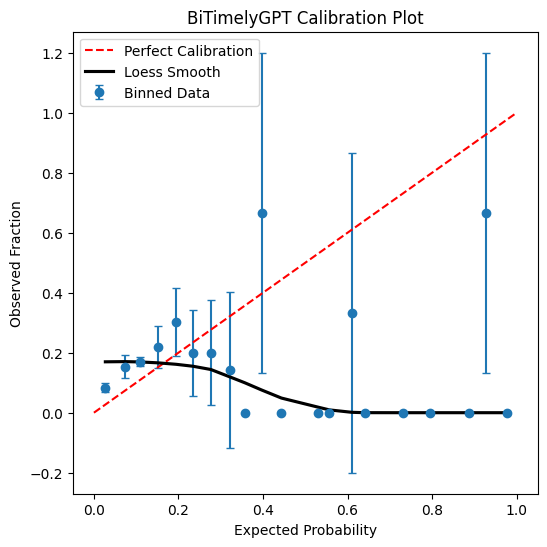

In [ ]:

########################################
# 3) Calibration Plot on set-c
########################################
import pandas as pd
import seaborn as sns

num_cuts = 24
df = pd.DataFrame({"prob": all_probs_test, "label": all_labels_test})

# 1) Bin predictions
df["bin"] = pd.cut(df["prob"], bins=num_cuts, include_lowest=True)

# 2) Group by bin, compute observed fraction, expected fraction, sample size, standard error
grouped = (
    df.groupby("bin")
    .agg(
        observed=("label", "mean"),
        expected=("prob", "mean"),
        n=("label", "count")
    )
    .reset_index()
)

grouped["se"] = np.sqrt(grouped["observed"] * (1 - grouped["observed"]) / grouped["n"])

# 3) Plot observed vs. expected
plt.figure(figsize=(6, 6))
plt.errorbar(
    x=grouped["expected"],
    y=grouped["observed"],
    yerr=1.96 * grouped["se"],
    fmt="o",
    capsize=3,
    label="Binned Data"
)
plt.plot([0, 1], [0, 1], "r--", label="Perfect Calibration")
sns.regplot(
    x="expected",
    y="observed",
    data=grouped,
    scatter=False,
    lowess=True,
    label="Loess Smooth",
    color="black"
)

plt.xlabel("Expected Probability")
plt.ylabel("Observed Fraction")
plt.title("BiTimelyGPT Calibration Plot")
plt.legend(loc="best")
plt.show()


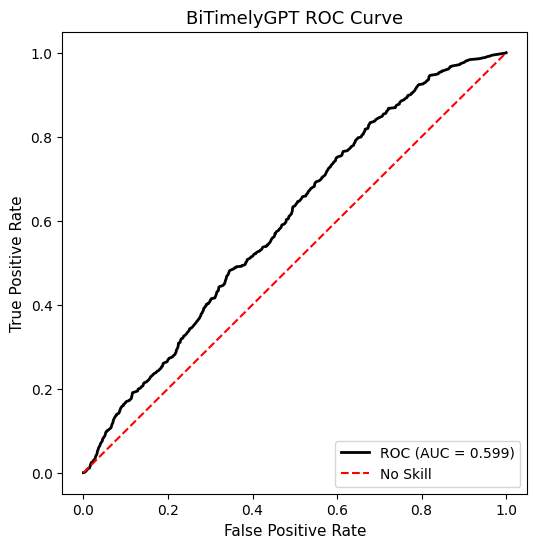

In [ ]:

########################################
# 4) ROC Curve on set-c
########################################
fpr_test, tpr_test, _ = roc_curve(all_labels_test, all_probs_test)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(6, 6))
sns.lineplot(x=fpr_test, y=tpr_test, color='black', linewidth=2,
             label=f'ROC (AUC = {roc_auc_test:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='No Skill')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('BiTimelyGPT ROC Curve', fontsize=13)
plt.legend(loc='lower right')
plt.show()